In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

In [3]:
import copy

def gauss_jordan_inverse(A):
    A = copy.deepcopy(A)
    n = len(A)
    
    I = [[0]*n for _ in range(n)]
    for i in range(n):
        I[i][i] = 1

    # Forward elimination
    for i in range(n):
        # Pivoting
        if A[i][i] == 0:
            t = i + 1
            while t < n and A[t][i] == 0:
                t += 1
            if t == n:
                raise ValueError("Matrix is singular")
            A[i], A[t] = A[t], A[i]
            I[i], I[t] = I[t], I[i]

        pivot = A[i][i]
        for k in range(n):
            A[i][k] /= pivot
            I[i][k] /= pivot

        for j in range(i+1, n):
            factor = A[j][i]
            for k in range(n):
                A[j][k] -= factor * A[i][k]
                I[j][k] -= factor * I[i][k]

    # Backward elimination
    for i in range(n-1, -1, -1):
        for j in range(i-1, -1, -1):
            factor = A[j][i]
            for k in range(n):
                A[j][k] -= factor * A[i][k]
                I[j][k] -= factor * I[i][k]

    return np.array(I)

In [4]:
def quantum_inspired_inverse(A, rank_k=10):
    """
    Approximate inverse using randomized low-rank projection.
    Works best when A has low-rank structure.
    """
    A = np.array(A)
    n = A.shape[0]

    # Random projection
    Omega = np.random.randn(n, rank_k)
    Y = A @ Omega

    # Orthonormal basis
    Q, _ = np.linalg.qr(Y)

    # Reduced matrix
    B = Q.T @ A @ Q

    # Invert reduced system
    B_inv = np.linalg.inv(B)

    # Lift back
    A_inv_approx = Q @ B_inv @ Q.T

    return A_inv_approx

In [5]:
import numpy as np

class QuantumInspiredSolver:
    def __init__(self, A):
        self.A = np.array(A)
        self.m, self.n = self.A.shape

        # Precompute row norms (length-square sampling)
        self.row_norms = np.linalg.norm(self.A, axis=1)**2
        self.prob = self.row_norms / np.sum(self.row_norms)

    def sample_row(self):
        i = np.random.choice(self.m, p=self.prob)
        return i, self.A[i]

    def solve(self, b, epochs=5000):
        b = np.array(b)
        x = np.zeros(self.n)

        for _ in range(epochs):
            i, a_i = self.sample_row()

            # residual for that row
            residual = np.dot(a_i, x) - b[i]

            # normalized update (critical!)
            x -= (residual / self.row_norms[i]) * a_i

        return x

def quantum_inspired_inverse2(A, epochs=5000):
    A = np.array(A)
    n = A.shape[0]

    solver = QuantumInspiredSolver(A)
    A_inv = np.zeros((n, n))

    for i in range(n):
        e = np.zeros(n)
        e[i] = 1

        x = solver.solve(e, epochs=epochs)
        A_inv[:, i] = x

    return A_inv

def solve_with_tracking(self, b, epochs=5000):
    b = np.array(b)
    x = np.zeros(self.n)
    errors = []

    for t in range(epochs):
        i, a_i = self.sample_row()
        residual = np.dot(a_i, x) - b[i]
        x -= (residual / self.row_norms[i]) * a_i

        # track full error occasionally
        if t % 100 == 0:
            err = np.linalg.norm(self.A @ x - b)
            errors.append(err)

    return x, errors

In [6]:
def lu_decomposition(A):
    """
    Performs LU decomposition with partial pivoting.
    Returns P, L, U such that PA = LU
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]

    L = np.zeros((n, n))
    U = A.copy()
    P = np.eye(n)

    for i in range(n):
        # ---- Pivoting ----
        max_row = np.argmax(abs(U[i:, i])) + i
        if i != max_row:
            U[[i, max_row]] = U[[max_row, i]]
            P[[i, max_row]] = P[[max_row, i]]
            L[[i, max_row], :i] = L[[max_row, i], :i]

        # ---- Elimination ----
        for j in range(i+1, n):
            factor = U[j, i] / U[i, i]
            L[j, i] = factor
            U[j] = U[j] - factor * U[i]

    np.fill_diagonal(L, 1)
    return P, L, U

In [7]:
def forward_substitution(L, b):
    n = len(b)
    y = np.zeros(n)

    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])

    return y

def backward_substitution(U, y):
    n = len(y)
    x = np.zeros(n)

    for i in range(n-1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]

    return x

In [8]:
def lu_inverse(A):
    """
    Compute inverse using LU decomposition
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]

    P, L, U = lu_decomposition(A)

    A_inv = np.zeros((n, n))
    I = np.eye(n)

    for i in range(n):
        # Solve PAx = Pb
        b = P @ I[:, i]

        y = forward_substitution(L, b)
        x = backward_substitution(U, y)

        A_inv[:, i] = x

    return A_inv

In [17]:
def random_matrix(n):
    # Well-conditioned random matrix (important!)
    A = np.random.randn(n, n)
    return A + n * np.eye(n)  # improve conditioning

def numpy_inverse(A):
    return np.linalg.inv(A)
def relative_error(A, A_inv):
    I = np.eye(A.shape[0])
    return np.linalg.norm(I - A @ A_inv, ord='fro') / np.linalg.norm(I, ord='fro')

In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt

sizes = [4, 8, 12, 16, 20, 24, 32, 40, 50,100,200,300,400,500]

time_gauss = []
time_lu = []
time_numpy = []
time_qi_proj = []   # your projection-based method
time_qi_sgd = []    # paper-faithful SGD method

runs = 3  # averaging

for n in sizes:
    tg = tl = tn = tqp = tqs = 0

    for _ in range(runs):
        A = random_matrix(n)

        # ---- Gauss-Jordan ----
        start = time.perf_counter()
        gauss_jordan_inverse(A.tolist())
        tg += time.perf_counter() - start

        # ---- LU ----
        start = time.perf_counter()
        lu_inverse(A)
        tl += time.perf_counter() - start

        # ---- NumPy ----
        start = time.perf_counter()
        np.linalg.inv(A)
        tn += time.perf_counter() - start

        # ---- Your projection method ----
        start = time.perf_counter()
        quantum_inspired_inverse(A)
        tqp += time.perf_counter() - start

        # ---- Paper SGD method ----
        start = time.perf_counter()
        quantum_inspired_inverse2(A, epochs=1000)  # reduced for fairness
        tqs += time.perf_counter() - start

    time_gauss.append(tg / runs)
    time_lu.append(tl / runs)
    time_numpy.append(tn / runs)
    time_qi_proj.append(tqp / runs)
    time_qi_sgd.append(tqs / runs)

    print(f"Done n={n}")

Done n=4
Done n=8
Done n=12
Done n=16
Done n=20
Done n=24
Done n=32
Done n=40
Done n=50
Done n=100
Done n=200
Done n=300
Done n=400
Done n=500


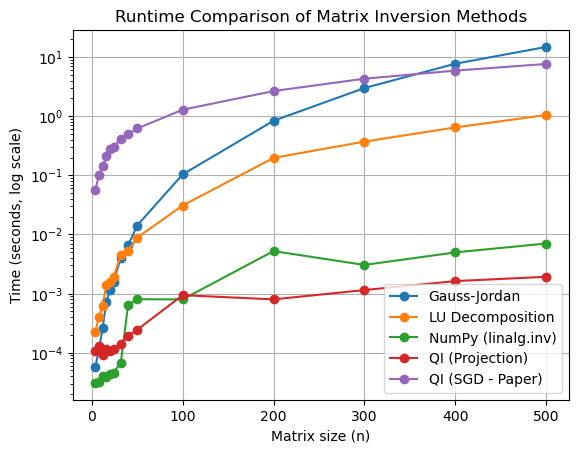

In [21]:
plt.figure()

plt.plot(sizes, time_gauss, marker='o', label="Gauss-Jordan")
plt.plot(sizes, time_lu, marker='o', label="LU Decomposition")
plt.plot(sizes, time_numpy, marker='o', label="NumPy (linalg.inv)")
plt.plot(sizes, time_qi_proj, marker='o', label="QI (Projection)")
plt.plot(sizes, time_qi_sgd, marker='o', label="QI (SGD - Paper)")

plt.xlabel("Matrix size (n)")
plt.ylabel("Time (seconds, log scale)")
plt.title("Runtime Comparison of Matrix Inversion Methods")

plt.yscale('log') 
plt.legend()
plt.grid()

plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

sizes = [4, 8, 12, 16, 20, 24, 32, 40, 50, 100, 200, 300, 400, 500]

error_gauss = []
error_lu = []
error_numpy = []
error_qi_proj = []
error_qi_sgd = []

runs = 3  # averaging for stability

for n in sizes:
    eg = el = en = eqp = eqs = 0

    for _ in range(runs):
        A = random_matrix(n)

        # ---- Gauss-Jordan ----
        try:
            A_g = gauss_jordan_inverse(A.tolist())
            eg += relative_error(A, A_g)
        except:
            eg += np.nan  # handle rare singular/numerical issues

        # ---- LU ----
        try:
            A_lu = lu_inverse(A)
            el += relative_error(A, A_lu)
        except:
            el += np.nan

        # ---- NumPy ----
        try:
            A_np = np.linalg.inv(A)
            en += relative_error(A, A_np)
        except:
            en += np.nan

        # ---- Projection-based method ----
        try:
            A_qp = quantum_inspired_inverse(A, rank_k=min(10, n))
            eqp += relative_error(A, A_qp)
        except:
            eqp += np.nan

        # ---- Paper (SGD) method ----
        try:
            A_qs = quantum_inspired_inverse2(A, epochs=1000)
            eqs += relative_error(A, A_qs)
        except:
            eqs += np.nan

    error_gauss.append(eg / runs)
    error_lu.append(el / runs)
    error_numpy.append(en / runs)
    error_qi_proj.append(eqp / runs)
    error_qi_sgd.append(eqs / runs)

    print(f"Error computed for n={n}")

Error computed for n=4
Error computed for n=8
Error computed for n=12
Error computed for n=16
Error computed for n=20
Error computed for n=24
Error computed for n=32
Error computed for n=40
Error computed for n=50
Error computed for n=100
Error computed for n=200
Error computed for n=300
Error computed for n=400
Error computed for n=500


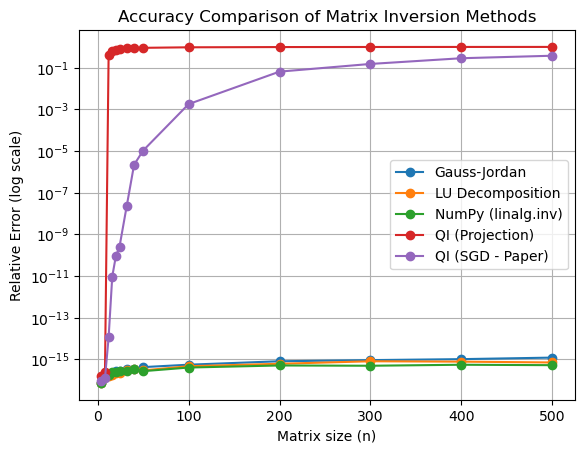

In [20]:
plt.figure()

plt.plot(sizes, error_gauss, marker='o', label="Gauss-Jordan")
plt.plot(sizes, error_lu, marker='o', label="LU Decomposition")
plt.plot(sizes, error_numpy, marker='o', label="NumPy (linalg.inv)")
plt.plot(sizes, error_qi_proj, marker='o', label="QI (Projection)")
plt.plot(sizes, error_qi_sgd, marker='o', label="QI (SGD - Paper)")

plt.xlabel("Matrix size (n)")
plt.ylabel("Relative Error (log scale)")
plt.title("Accuracy Comparison of Matrix Inversion Methods")

plt.yscale('log')  # 🔥 very important
plt.legend()
plt.grid()

plt.show()

In [50]:
## what if we generated sparse matrices? Would the quantum-inspired method be more efficient?

In [22]:
def random_sparse_matrix(n, density=0.1):
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if random.random() < density:
                A[i, j] = random.uniform(-1, 1)
    return A +n*np.eye(n)

In [23]:
sizes = [4, 8, 12, 16, 20, 24, 32, 40,50,100,200,300,400,500]

error_gauss = []
error_lu = []
error_numpy = []
error_qi = []

runs = 3

for n in sizes:
    eg = el = en = eq = 0

    for _ in range(runs):
        A = random_sparse_matrix(n)

        # ---- Gauss ----
        A_inv_g = gauss_jordan_inverse(A.tolist())
        eg += relative_error(A, A_inv_g)

        # ---- LU ----
        A_inv_l = lu_inverse(A)
        el += relative_error(A, A_inv_l)

        # ---- NumPy ----
        A_inv_n = numpy_inverse(A)
        en += relative_error(A, A_inv_n)

        # ---- Quantum ----
        A_inv_q = quantum_inspired_inverse(A)
        eq += relative_error(A, A_inv_q)

    error_gauss.append(eg / runs)
    error_lu.append(el / runs)
    error_numpy.append(en / runs)
    error_qi.append(eq / runs)
    print(f"Error done n={n}")

Error done n=4
Error done n=8
Error done n=12
Error done n=16
Error done n=20
Error done n=24
Error done n=32
Error done n=40
Error done n=50
Error done n=100
Error done n=200
Error done n=300
Error done n=400
Error done n=500


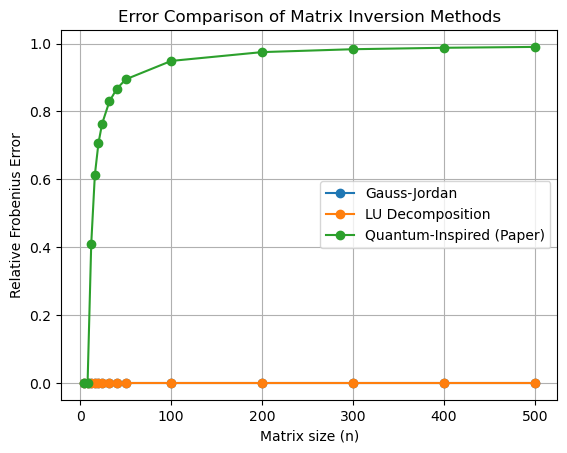

In [24]:
plt.figure()

plt.plot(sizes, error_gauss, marker='o', label="Gauss-Jordan")
plt.plot(sizes, error_lu, marker='o', label="LU Decomposition")
plt.plot(sizes, error_qi, marker='o', label="Quantum-Inspired (Paper)")

plt.xlabel("Matrix size (n)")
plt.ylabel("Relative Frobenius Error")
plt.title("Error Comparison of Matrix Inversion Methods")

plt.legend()
plt.grid()
plt.show()